In [2]:
# --- Step 1: Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import matplotlib.ticker as mtick

sns.set_style("whitegrid") # Set the style for plots 
plt.rcParams['figure.figsize'] = (12, 7) # Set a default figure size


In [ ]:
# --- Step 2: Load All Cleaned Datasets ---
# This cell loads all the pre-processed CSV files.
# IMPORTANT: Adjust the file paths below to match the location where you saved your files.

try:
    # Core data files
    df_demo = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
    df_bp = pd.read_csv("../data/combined_blood_pressure_data.csv") 


    df_smoking = pd.read_csv("../data/questionaire_data/cleaned_smoking_combined.csv")
    df_alcohol = pd.read_csv("../data/questionaire_data/cleaned_alcohol_use.csv")
    df_diabetes = pd.read_csv("../data/questionaire_data/cleaned_diabetes.csv")
    #can load other cleaned files here as needed - maybe import from SQL later on: Quest_physical_activity,Quest_sleep
   
    
    print("All datasets loaded successfully!")
    print(f"Demographics data shape: {df_demo.shape}")
    print(f"BMI data shape: {df_bmi.shape}")
    print(f"Blood Pressure data shape: {df_bp.shape}")

except FileNotFoundError:
    print(f"File Not Found Error!")


All datasets loaded successfully!
Demographics data shape: (11933, 13)
BMI data shape: (8860, 10)
Blood Pressure data shape: (7801, 14)


In [6]:
# calculate sum of exam weight  ->  is a statistical weighting variable in NHANES data that ensures nationally representative estimates by adjusting for sampling design and non-response across all participants in the survey cycle.
total_demo_exam_weight = df_demo['Exam_Weight'].sum()
total_demo_interview_weight = df_demo['Interview_Weight'].sum()

print(f"Exam_Weight Sum: {total_demo_exam_weight:,.0f}")
print(f"Interview_Weight Sum: {total_demo_interview_weight:,.0f}")
# The weighted sum should be approximately equal to the total population of the United States: ~327 million.

Exam_Weight Sum: 327,013,564
Interview_Weight Sum: 327,013,528


In [7]:
# Check the participant with the maximum Exam_Weight
max_row = df_demo.loc[df_demo['Exam_Weight'].idxmax()]
print(f"💥 Max Exam_Weight value: {max_row['Exam_Weight']:.0f}")

# Count participants with large weights
large_weight_count = df_demo[df_demo['Exam_Weight'] > 200000].shape[0]
print(f"Participants with Exam_Weight > 200,000: {large_weight_count}")

# Check the minimum non-zero Exam_Weight value
min_nonzero_weight = df_demo[df_demo['Exam_Weight'] > 0]['Exam_Weight'].min()
print(f"\n💥 Minimum non-zero Exam_Weight value: {min_nonzero_weight:.0f}")

# Count participants with small but non-zero weights
small_weight_count = df_demo[(df_demo['Exam_Weight'] > 0) & (df_demo['Exam_Weight'] < 10000)].shape[0]
print(f"Participants with 0 < Exam_Weight < 10,000: {small_weight_count}")



# Why use effective sample size (n_eff)? (comment for hypothesis testing later on)
# --------------------------------------
# NHANES data uses survey weights (Exam_Weight) to make estimates representative of the U.S. population.
# However, these weights vary dramatically between participants — some represent only a few thousand people,
# while others represent over 100,000 individuals.
#
# Because of this large variation in weights, using the raw sample size (n) to calculate standard error
# would severely underestimate uncertainty. That's why we use the "effective sample size" (n_eff), which adjusts for
# the unequal weighting and provides a more accurate estimate of precision.
#
# n_eff -- Effective sample size is computed as:
    # eight_sum = weights.sum()
    # weight_sq_sum = (weights**2).sum()
    # n_eff = (weight_sum ** 2) / weight_sq_sum 
# This is a standard formula in complex survey design and is used to reflect the true amount of independent information
# contributed by a weighted sample.

💥 Max Exam_Weight value: 227108
Participants with Exam_Weight > 200,000: 7

💥 Minimum non-zero Exam_Weight value: 4582
Participants with 0 < Exam_Weight < 10,000: 185


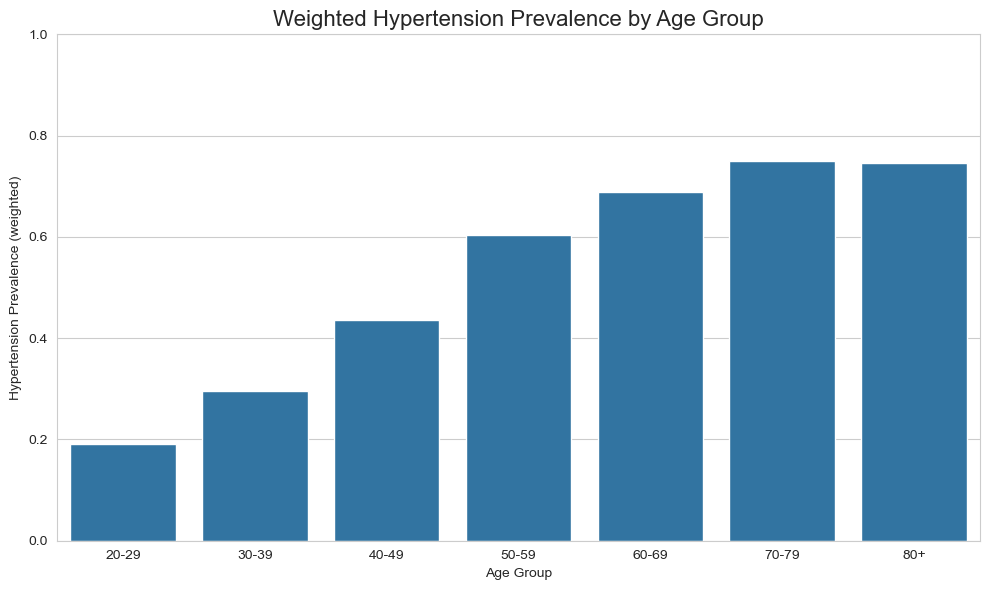

In [8]:
# Hypothesis 1: the prevalence of hypertension increases with age.
df_hp1 = pd.merge(df_demo, df_bp, on="Participant_ID")

# Create age groups
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df_hp1['Age_Group'] = pd.cut(df_hp1['Age_Years'], bins=age_bins, labels=age_labels, right=False) # right=False excludes age bins edge values 

# Keep non-missing values only
df_filtered = df_hp1.dropna(subset=['Hypertensive', 'Exam_Weight', 'Age_Group'])

# Calculate the weighted hypertension prevalence for each age group.
weighted_results = (
    df_filtered
    .groupby("Age_Group")
    # Prevalence = weighted number of cases / weighted total population = sum(Hypertensive × Exam_Weight) / sum(Exam_Weight)
        # important to keep to represent US population
        # Hypertensive is in Boolean format: TRUE / FALSE. After loading it in Pandas, it will become Python's True / False, which is essentially equivalent to 1 and 0.
    .apply(lambda x: np.average(x['Hypertensive'], weights=x['Exam_Weight'])) 
    .reset_index(name='Weighted_Hypertension_Prevalence')
)

# Visualization
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=weighted_results, x='Age_Group', y='Weighted_Hypertension_Prevalence')
plt.title("Weighted Hypertension Prevalence by Age Group", fontsize=16)
plt.ylabel("Hypertension Prevalence (weighted)")
plt.xlabel("Age Group")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Output interpretation: 
    # Age emerges as a strong independent risk factors for hypertension in US adults, with prevalence nearly quadrupling from young adulthood to advanced age.


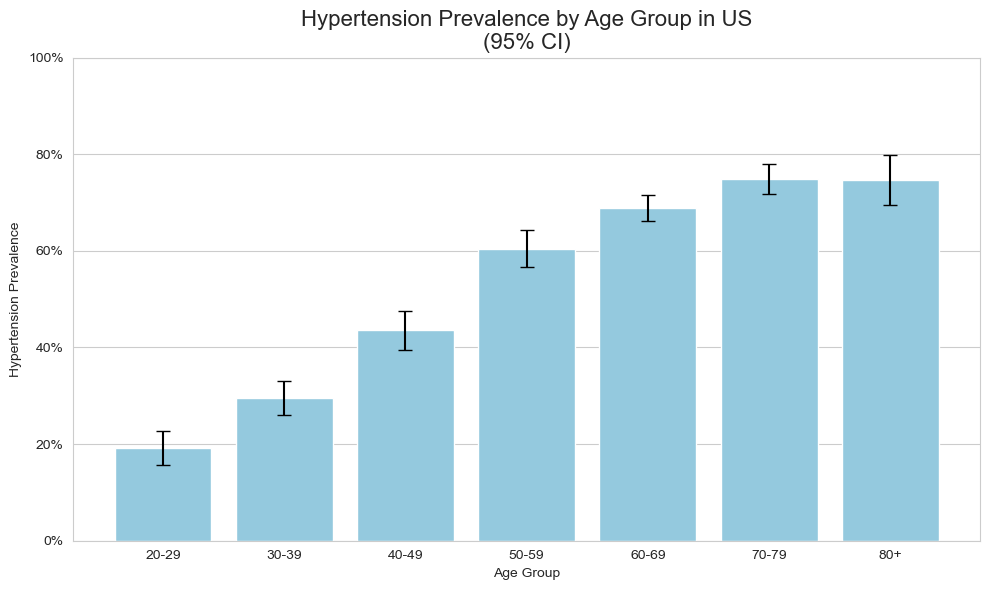

In [10]:
# Visulization 2
# Merge data
df_hypothesis_1 = pd.merge(df_demo, df_bp, on="Participant_ID")

# IMPORTANT:清洗有效记录
df_hypothesis_1 = df_hypothesis_1[(df_hypothesis_1['Exam_Weight'] > 0) & df_hypothesis_1['Hypertensive'].notna()]

# Create age groups
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df_hypothesis_1['Age_Group'] = pd.cut(df_hypothesis_1['Age_Years'], bins=age_bins, labels=age_labels, right=False)

# Keep valid rows
df_filtered = df_hypothesis_1.dropna(subset=['Hypertensive', 'Exam_Weight', 'Age_Group'])

# Compute prevalence + 95% CI per group
def compute_weighted_prevalence_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum  # Effective sample size
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    })

weighted_results_ci = (
    df_filtered
    .groupby("Age_Group")
    .apply(compute_weighted_prevalence_ci)
    .reset_index()
)

# --- Visualization with error bars ---
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=weighted_results_ci,
    x='Age_Group',
    y='Weighted_Hypertension_Prevalence',
    color='skyblue',
    ci=None
)

# Add error bars manually
plt.errorbar(
    x=range(len(weighted_results_ci)),
    y=weighted_results_ci['Weighted_Hypertension_Prevalence'],
    yerr=[
        weighted_results_ci['Weighted_Hypertension_Prevalence'] - weighted_results_ci['CI_Lower'],
        weighted_results_ci['CI_Upper'] - weighted_results_ci['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, linewidth=1.5
)

plt.title("Hypertension Prevalence by Age Group in US\n(95% CI)", fontsize=16)
plt.ylabel("Hypertension Prevalence")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.xlabel("Age Group")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --- Save output for Tableau ---
weighted_results_ci.to_csv("../output/hypertension_by_age_group_with_ci.csv", index=False)


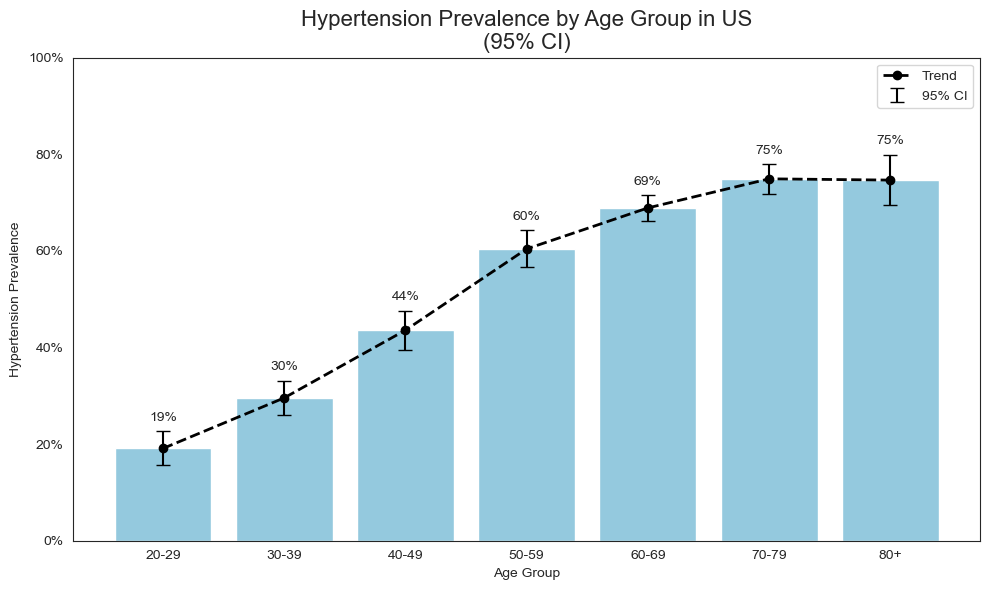

In [13]:
# visualization 3 

# 设置风格为无grid
sns.set_style("white")  # 移除白色网格线

plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(
    data=weighted_results_ci,
    x='Age_Group',
    y='Weighted_Hypertension_Prevalence',
    color='skyblue',
    ci=None
)

# 添加误差条
plt.errorbar(
    x=range(len(weighted_results_ci)),
    y=weighted_results_ci['Weighted_Hypertension_Prevalence'],
    yerr=[
        weighted_results_ci['Weighted_Hypertension_Prevalence'] - weighted_results_ci['CI_Lower'],
        weighted_results_ci['CI_Upper'] - weighted_results_ci['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, linewidth=1.5, label='95% CI'  
)

# 添加趋势线（连接柱子的中心）
plt.plot(
    range(len(weighted_results_ci)),
    weighted_results_ci['Weighted_Hypertension_Prevalence'],
    color='black', linestyle='--', linewidth=2, marker='o', label='Trend'
)

# 百分比格式
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# 标题和轴标签
plt.title("Hypertension Prevalence by Age Group in US\n(95% CI)", fontsize=16)
plt.ylabel("Hypertension Prevalence")
plt.xlabel("Age Group")


plt.ylim(0, 1)
plt.legend()

for i, row in weighted_results_ci.iterrows():
    plt.text(
        x=i,
        y=row['CI_Upper'] + 0.015,
        s=f"{row['Weighted_Hypertension_Prevalence']*100:.0f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig("../visualization/hypertension_prevalence_by_age_group_CI_trend.png", dpi=300, bbox_inches='tight')
plt.show()

